In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 
import requests
import json

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer, PowerTransformer, QuantileTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.compose import ColumnTransformer

## Step 1 : Project planning and Problem Framing :

### What is Data Analysis?

### Data Analysis is the process of inspecting, cleansing, transforming, and modeling data with the goal of discovering useful information, informing conclusions, and supporting decision-making.

## Steps in Data science project:

1. Project planning and Problem Framing
2. Data Collection
3. Data Cleaning and Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Model Deployment

## How to frame this Dataset as a ML problem?

- Objective: Predict a target variable (e.g., customer segment, purchase likelihood, or income group) using demographic features like Age, Gender, City, and Income.

- Type of Problem: Depends on target → Classification (if categories like “High/Low Income”) or Regression (if predicting continuous income).

- Goal: Enable data-driven decisions such as customer profiling, targeted marketing, or segmentation.

## Step 2 : Data Import and Understanding

In [2]:
csv_data = pd.read_csv('Customer_Dataset.csv')

df_csv = csv_data.copy()

df_csv.head()

,Customer_ID,Name,Age,Gender,City,Income
0,1717,Krishna Kumar,58.0,Other,Ahmedabad,1896028.0
1,4831,Sai Reddy,68.0,Male,Hyderabad,NaN
2,4668,Shaurya Das,65.0,Other,Ahmedabad,398801.0
3,4098,Vivaan Gupta,24.0,Female,Ahmedabad,312407.0
4,222,Sai Iyer,39.0,Female,Delhi,1219604.0


In [3]:
json_data = pd.read_json('transactions.json')

df_json = json_data.copy()

df_json.head()  

,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07


In [4]:
conn = sqlite3.connect('product_database.db')


sql_query = "SELECT * FROM products"
df_sql = pd.read_sql_query(sql_query, conn)

df_sql.head()

,product_id,product_name,category,price,stock,supplier
0,P10000,portable ssd,Audio,NaN,4092.0,Hill-Burns
1,P10001,Wireless Mouse,Mobile Accessories,2334.08,102.0,Wang-Kramer
2,P10002,Mechanical Keyboard,Computer,1399.81,458.0,Townsend-King
3,P10003,Smart Watch,Audio,2351.02,87.0,Harmon LLC
4,P10004,Portable SSD,Office,1437.72,130.0,Clark Ltd


In [5]:
url = ' https://dummyjson.com/users'

response = requests.get(url)

data = response.json()

df_API = pd.DataFrame(data)

df_API.head()

,users,total,skip,limit
0,"{'id': 1, 'firstName': 'Emily', 'lastName': 'J...",208,0,30
1,"{'id': 2, 'firstName': 'Michael', 'lastName': ...",208,0,30
2,"{'id': 3, 'firstName': 'Sophia', 'lastName': '...",208,0,30
3,"{'id': 4, 'firstName': 'James', 'lastName': 'D...",208,0,30
4,"{'id': 5, 'firstName': 'Emma', 'lastName': 'Mi...",208,0,30


In [6]:
df_sql.info()
df_sql.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    5030 non-null   object 
 1   product_name  5030 non-null   object 
 2   category      5030 non-null   object 
 3   price         5013 non-null   float64
 4   stock         5011 non-null   float64
 5   supplier      5030 non-null   object 
dtypes: float64(2), object(4)
memory usage: 235.9+ KB


,price,stock
count,5013.000000,5011.000000
mean,2741.296599,258.148274
std,3859.304620,223.428419
min,100.540000,0.000000
25%,1668.510000,127.000000
50%,2506.300000,248.000000
75%,3307.460000,378.000000
max,77850.610000,4719.000000


In [7]:
df_csv.info()
df_csv.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  5100 non-null   int64  
 1   Name         5100 non-null   object 
 2   Age          4741 non-null   float64
 3   Gender       4743 non-null   object 
 4   City         4744 non-null   object 
 5   Income       4746 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 239.2+ KB


,Customer_ID,Age,Income
count,5100.00000,4741.000000,4.746000e+03
mean,2497.00549,43.694368,1.183073e+06
std,1445.29538,15.146738,8.414627e+05
min,1.00000,18.000000,2.001890e+05
25%,1242.75000,30.000000,6.404050e+05
50%,2496.50000,44.000000,1.107394e+06
75%,3752.25000,57.000000,1.573594e+06
max,5000.00000,69.000000,7.955116e+06


## Step 3 : Exploratory Data Analysis (EDA)

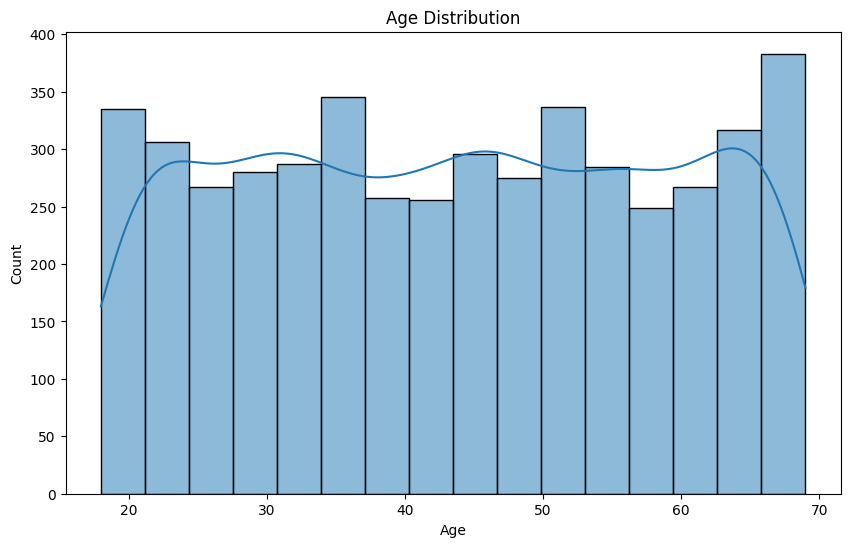

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df_csv["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

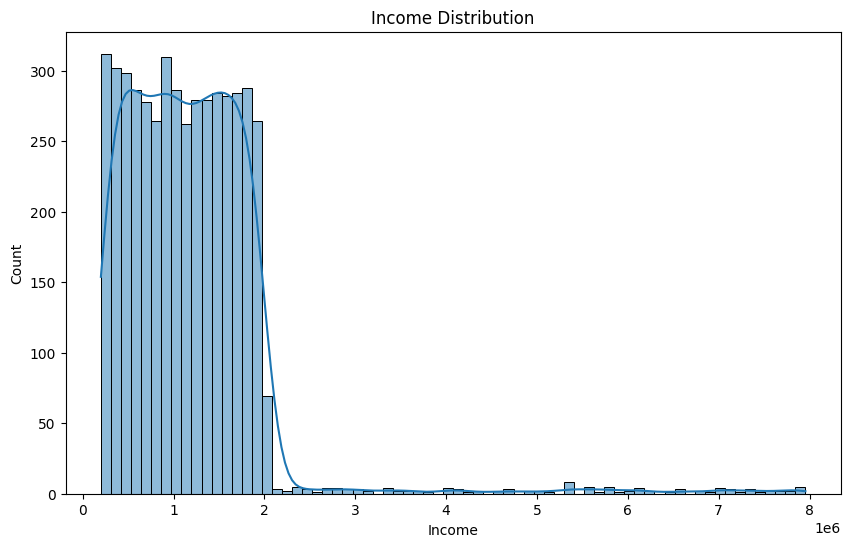

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df_csv["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

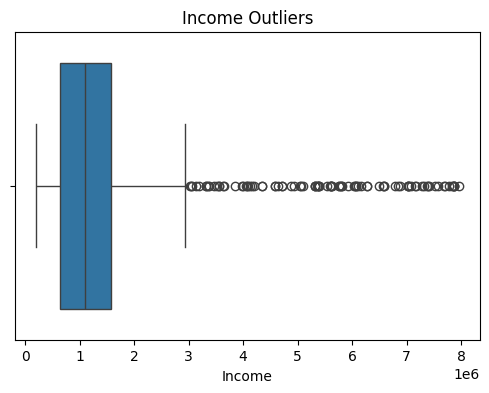

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_csv["Income"])
plt.title("Income Outliers")
plt.show()

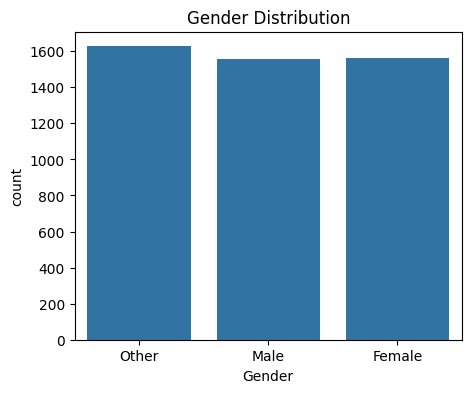

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df_csv)
plt.title("Gender Distribution")
plt.show()

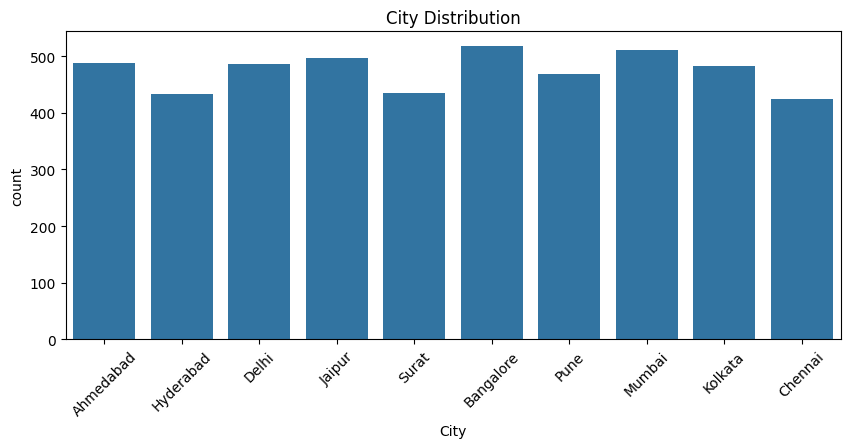

In [12]:
plt.figure(figsize=(10,4))
sns.countplot(x="City", data=df_csv)
plt.xticks(rotation=45)
plt.title("City Distribution")
plt.show()

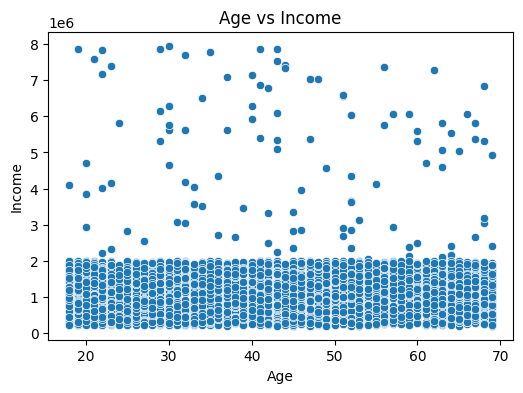

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Income", data=df_csv)
plt.title("Age vs Income")
plt.show()

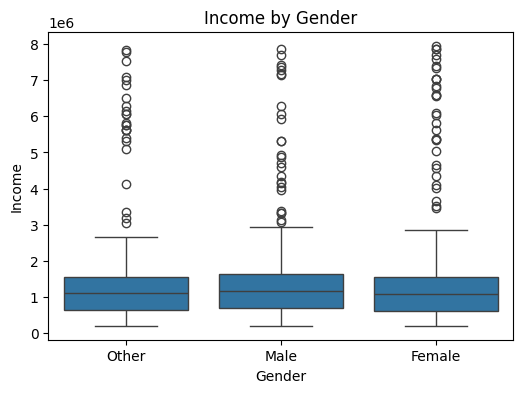

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Income", data=df_csv)
plt.title("Income by Gender")
plt.show()

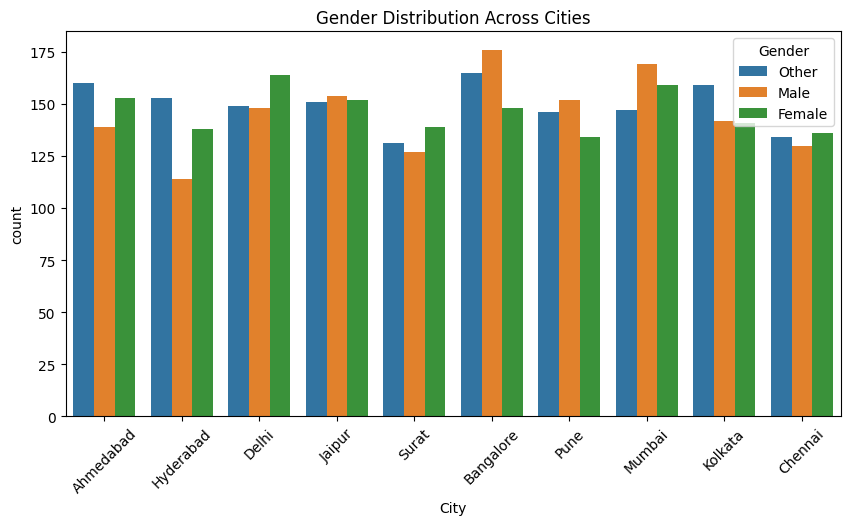

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x="City", hue="Gender", data=df_csv)
plt.xticks(rotation=45)
plt.title("Gender Distribution Across Cities")
plt.show()

In [16]:
df_csv.drop(columns=["Customer_ID", "Name"], inplace=True)

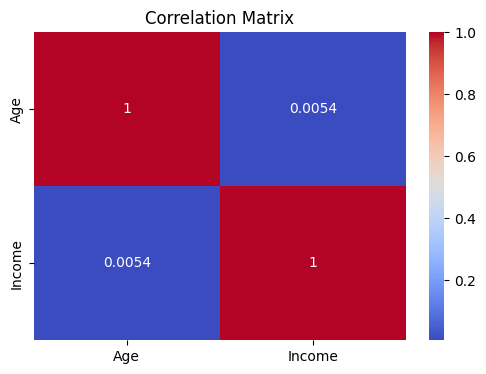

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df_csv.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Step 4 : Handling Missing Values

In [18]:
missing_values = df_csv.isnull().sum()
missing_percentage = (missing_values / len(df_csv)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df

,Missing Values,Percentage
Age,359,7.039216
Gender,357,7.000000
City,356,6.980392
Income,354,6.941176


In [19]:
num_cols = ["Age", "Income"]
cat_cols = ["Gender", "City"]

In [20]:
knn_imputer = KNNImputer(n_neighbors=5)

df_csv[num_cols] = knn_imputer.fit_transform(df_csv[num_cols])

df_csv.head()

,Age,Gender,City,Income
0,58.0,Other,Ahmedabad,1896028.0
1,68.0,Male,Hyderabad,1154212.0
2,65.0,Other,Ahmedabad,398801.0
3,24.0,Female,Ahmedabad,312407.0
4,39.0,Female,Delhi,1219604.0


In [21]:
cat_imputer = SimpleImputer(strategy="most_frequent")
df_csv[cat_cols] = cat_imputer.fit_transform(df_csv[cat_cols])

df_csv.head()

,Age,Gender,City,Income
0,58.0,Other,Ahmedabad,1896028.0
1,68.0,Male,Hyderabad,1154212.0
2,65.0,Other,Ahmedabad,398801.0
3,24.0,Female,Ahmedabad,312407.0
4,39.0,Female,Delhi,1219604.0


In [22]:
missing_values = df_csv.isnull().sum()
missing_percentage = (missing_values / len(df_csv)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df

,Missing Values,Percentage
Age,0,0.0
Gender,0,0.0
City,0,0.0
Income,0,0.0


## Step 5 : Outlier Handling 

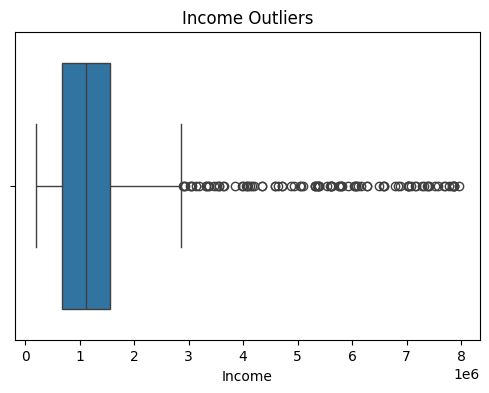

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_csv["Income"])
plt.title("Income Outliers")
plt.show()

In [24]:
df_csv = df_csv.drop_duplicates(keep="first")

In [25]:
df_csv

,Age,Gender,City,Income
0,58.0,Other,Ahmedabad,1896028.0
1,68.0,Male,Hyderabad,1154212.0
2,65.0,Other,Ahmedabad,398801.0
3,24.0,Female,Ahmedabad,312407.0
4,39.0,Female,Delhi,1219604.0
...,...,...,...,...
5094,21.0,Other,Bangalore,222831.0
5095,48.0,Female,Kolkata,1303789.0
5096,26.0,Male,Jaipur,1098466.8
5098,67.0,Male,Mumbai,1892043.0


In [26]:
from scipy.stats.mstats import winsorize

df_csv['Income'] = winsorize(df_csv['Income'], limits=[0.01, 0.01])

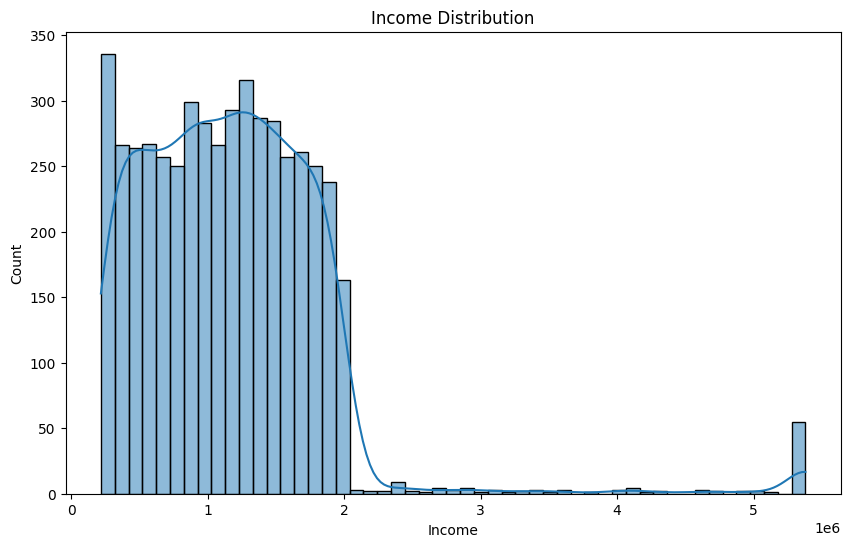

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(df_csv["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

## Step 6 : Feature Engineering

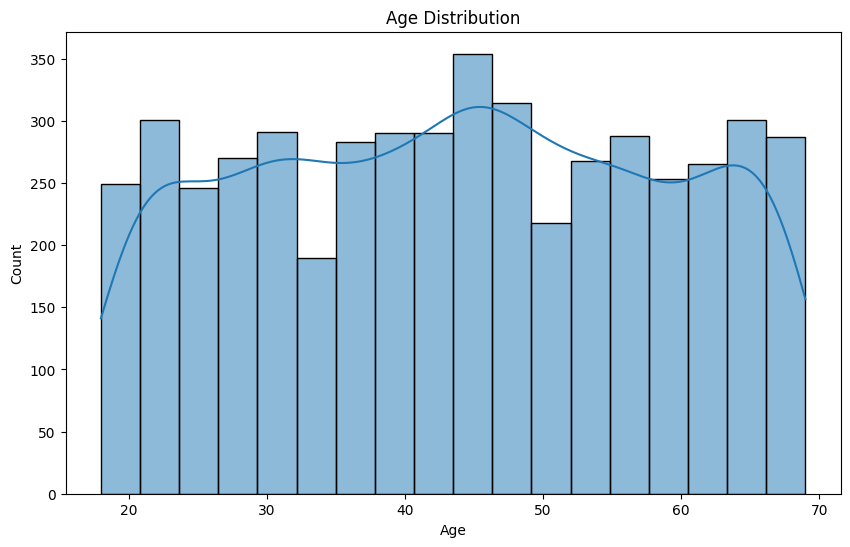

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df_csv["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

In [29]:
bins = [17, 25, 35, 50, 69]
labels = ['Young', 'Adult', 'MidAge', 'Senior']

df_csv['Age_Group'] = pd.cut(df_csv['Age'], bins=bins, labels=labels)

In [30]:
df_csv.head()

,Age,Gender,City,Income,Age_Group
0,58.0,Other,Ahmedabad,1896028.0,Senior
1,68.0,Male,Hyderabad,1154212.0,Senior
2,65.0,Other,Ahmedabad,398801.0,Senior
3,24.0,Female,Ahmedabad,312407.0,Young
4,39.0,Female,Delhi,1219604.0,MidAge


In [31]:
df_csv["Income"] = np.log1p(df_csv["Income"])

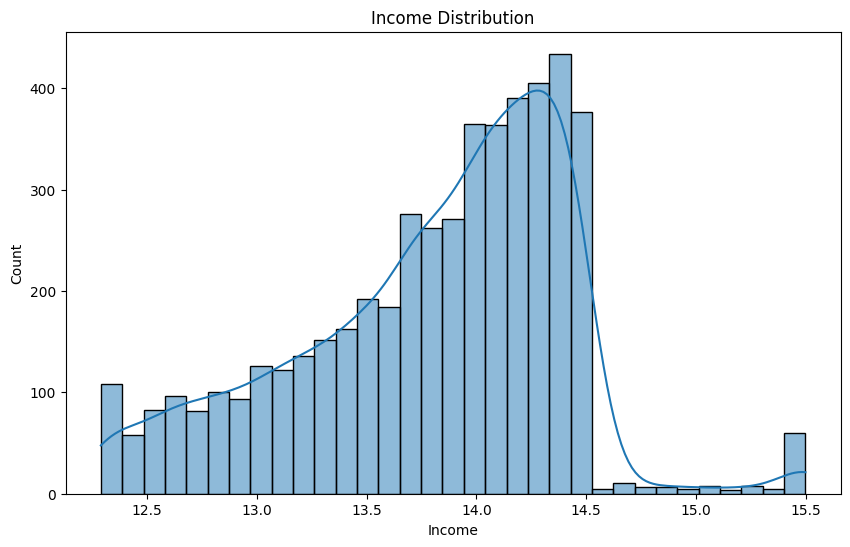

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df_csv["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

## Step 7 : Encoding 

In [33]:
ohe = OneHotEncoder( drop = 'first', sparse_output = False , handle_unknown = 'ignore')   

cat_cols = ['Gender' , 'City']

encoded_array = ohe.fit_transform(df_csv[cat_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_csv.index
)

df_csv = df_csv.drop(columns=cat_cols)
df_csv = pd.concat([df_csv, encoded_df], axis=1)

In [34]:
df_csv.head()

,Age,Income,Age_Group,Gender_Male,Gender_Other,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Mumbai,City_Pune,City_Surat
0,58.0,14.455272,Senior,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,68.0,13.958929,Senior,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,65.0,12.896220,Senior,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,24.0,12.652065,Young,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39.0,14.014038,MidAge,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
Ord_enc = OrdinalEncoder(
    categories=[['Young', 'Adult', 'MidAge', 'Senior']]
)

df_csv['Age_Group'] = Ord_enc.fit_transform(df_csv[['Age_Group']])

df_csv.head()

,Age,Income,Age_Group,Gender_Male,Gender_Other,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Mumbai,City_Pune,City_Surat
0,58.0,14.455272,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,68.0,13.958929,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,65.0,12.896220,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,24.0,12.652065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39.0,14.014038,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 8 : Feature Scaling 

In [39]:
scaler = StandardScaler()

df_csv[['Age', 'Income']] = scaler.fit_transform(df_csv[['Age', 'Income']])

In [40]:
df_csv.head()

,Age,Income,Age_Group,Gender_Male,Gender_Other,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Mumbai,City_Pune,City_Surat
0,0.966496,1.063711,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.645507,0.263902,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.441803,-1.448550,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.342141,-1.841982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.323625,0.352704,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
Cleaned_Dataset = df_csv.copy()

Cleaned_Dataset.head()

,Age,Income,Age_Group,Gender_Male,Gender_Other,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Mumbai,City_Pune,City_Surat
0,0.966496,1.063711,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.645507,0.263902,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.441803,-1.448550,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.342141,-1.841982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.323625,0.352704,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
